# Q2. Unsupervised Learning

In [1]:
import pandas as pd                          
import numpy as np                           
import matplotlib.pyplot as plt             
import seaborn as sns                        

from sklearn.preprocessing import StandardScaler   
from sklearn.cluster import KMeans                 
from sklearn.decomposition import PCA             

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('q2_customers.csv') #loading the dataset

# first 5 rows
print("First 5 rows of dataset:")
df.head()

First 5 rows of dataset:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
print("Shape:", df.shape) #number of rows and columns 
print("\nColumns:", df.columns.tolist())

Shape: (500, 6)

Columns: ['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']


In [8]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


#### Why scaling is essential before applying K-Means
Scaling is essential because without scaling features with larger magnitudes  dominate features with smaller magnitudes causing the model to produce inaccurate, biased clusters that ignore smaller-scaled variables.Scaling brings all features to a similar comparable scale ensuring that each feature contributes equally to the calculation of centroids and distance regardless of its original units.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       ...,
       [ 0.24618021,  0.1432203 ,  0.11016555, -0.78158167, -0.79489349,
        -0.68068477],
       [-0.30890482, -0.23321247,  0.11016555, -0.27997151, -0.04966825,
         0.55095233],
       [-1.41907487, -1.2411359 ,  1.23814046, -0.79962203, -0.67404615,
        -1.50177617]], shape=(500, 6))

## 2. Choosing K — Elbow Method 

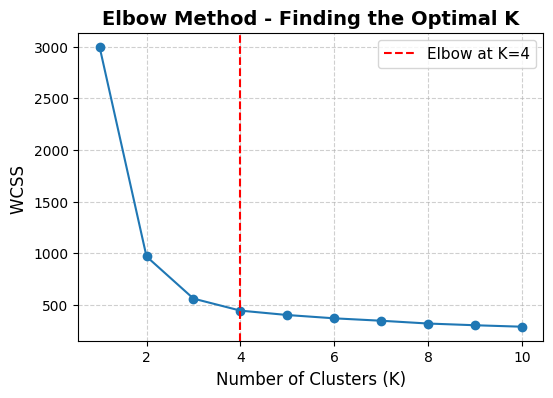

In [10]:
wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method - Finding the Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS ', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mark the elbow point
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at K=4')
plt.legend(fontsize=11)

plt.grid(True)
plt.show()

It can be observed that from K=1 to 4 WCSS drops steeply while the graph changes from K=4 onwards where the drop becomes gradual and latter flattens out.
- Hence The "elbow" (the sharp bend) is at **K = 4**. So it is the optimal number of clusters.

## 3. K-Means Clustering

In [11]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10 )

kmeans.fit(X_scaled)
labels = kmeans.labels_
df['cluster'] = labels

print ("Cluster counts")
print(df['cluster'].value_counts().sort_index())

Cluster counts
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [12]:
centroids_scaled = kmeans.cluster_centers_       # Centroids in scaled space
centroids_original = scaler.inverse_transform(centroids_scaled)  # Convert back to original units

# Wrap in a DataFrame for a nice table view
centroids_df = pd.DataFrame(
    centroids_original,
    columns=df.columns[:-1],   # Exclude the 'cluster' column
    index=[f"Cluster {i}" for i in range(OPTIMAL_K)]
)

print("Cluster Centroids (in original units — average customer per cluster):")
centroids_df.round(1)

Cluster Centroids (in original units — average customer per cluster):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.7,14847.4,14.3,559.0,9.1,2.1
Cluster 1,57.0,89814.1,2.5,5296.4,148.0,7.5
Cluster 2,40.4,43340.7,8.2,2021.7,35.2,4.4
Cluster 3,56.5,89036.2,2.6,5751.0,65.2,7.5


#### Interpretation
- **Cluster 0** - Young, frequent low-spenders (High engagement but low monetisation)
- **Cluster 1** Older High-Value Lapsed Customers (They are older, big spenders who bought across every category. But they haven't been seen in almost 5 months)
- **Cluster 2** Middle-Aged Mainstream Shoppers (stable customer base who shop regularly, spend moderately)
- **Cluster 3** Older High-Value Active Loyalists

## 4. Dimensionality Reduction with PCA

In [13]:
pca = PCA(n_components=2) #reducing 6 features to 2
X_pca = pca.fit_transform(X_scaled)

print(f"Original data shape: {X_scaled.shape}  → {X_scaled.shape[1]} features")
print(f"After PCA shape:     {X_pca.shape}  → {X_pca.shape[1]} components")

Original data shape: (500, 6)  → 6 features
After PCA shape:     (500, 2)  → 2 components


In [ ]:
#explained variance ratio
explained = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(f"  PC1 captures: {explained[0]*100:.2f}% of the total variance")
print(f"  PC2 captures: {explained[1]*100:.2f}% of the total variance")
print(f"  Combined:     {sum(explained)*100:.2f}% of the total variance")

Explained Variance Ratio:
  PC1 captures: 83.56% of the total variance
  PC2 captures: 5.57% of the total variance
  Combined:     89.13% of the total variance


In [15]:
#Feature loadings
loadings_df = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],   # original feature names (exclude 'cluster')
    index=['PC1', 'PC2']
)

print("Feature Loadings:")
print("(Positive = feature increases with PC, Negative = feature decreases with PC)")
loadings_df.round(3)

Feature Loadings:
(Positive = feature increases with PC, Negative = feature decreases with PC)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.412,0.422,-0.410,0.412,0.379,0.414
PC2,-0.259,-0.033,0.208,-0.195,0.911,-0.140


### Interpreting PC1 and PC2

- **PC1** — "Overall Customer Value" (captures 83.56% of variance)
<br>PC1 has large loadings of similar magnitude across almost all features:

`annual_spend` (+0.422), `age` (+0.412), `basket_size` (+0.412), `num_categories_purchased` (+0.414), `days_since_last_visit` (+0.379) → all strongly positive
`visits_per_month` (-0.410) → strongly negative

This means PC1 represents Purchasing power or spending intensity.A customer scores high on PC1 if they spend a lot, buy across many categories, have large baskets but visit less frequently ( high-value shoppers may do fewer bigger trips). A low PC1 score means frequent small visits and low spending.
The fact that PC1 alone explains 83.56% of variance is significant , it tells that most of the meaningful variation in the customer base comes down to this single spending vs frequency trade-off.

- **PC2** — "Recency / Inactivity" (captures 5.57% of variance)
<br>PC2 is almost entirely dominated by one feature:

`days_since_last_visit` (+0.911) → overwhelmingly positive
Everything else has small loadings (all below ±0.26)

So PC2 is essentially a recency axis .It separates customers purely by how long ago they last visited. A customer high on PC2 hasn't been seen in a long time. A customer low on PC2 visited recently.

## 5.Cluster Visualisation

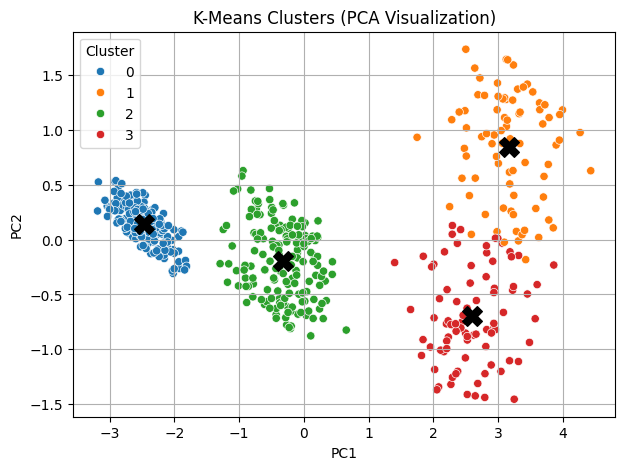

In [23]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": labels
})

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="tab10")

# Plot the cluster centroids projected onto PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1],
    c='black', marker='X', s=200,
)
plt.title("K-Means Clusters (PCA Visualization)")
plt.grid(True)
plt.show()